In [1]:
import numpy as np
import pickle
import torch.utils.data as data_0
import torch
import torch.nn as nn
import matplotlib.pyplot as plt
import os
from scipy.integrate import odeint


In [2]:
def createFolder(directory):
    try:
        if not os.path.exists(directory):
            os.makedirs(directory)
    except OSError:
        print ('Error: Creating directory. ' +  directory)

def covariance_1(ampl, size):
    
    coeff = np.zeros(2*size)
    
    for i in range(size):
        coeff[i] = np.exp(-i/ampl)
    
    for i in range(size-1):
        coeff[2*size-1-i] = np.exp(-(i+1)/ampl)

    return coeff

def covariance_2(ampl, size):
    
    coeff = np.zeros(2*size)
    
    for i in range(size):
        coeff[i] = np.exp(-(i**2)/ampl**2)
    
    for i in range(size-1):
        coeff[2*size-1-i] = np.exp(-(i+1)**2/ampl**2)

    return coeff


def generator_1D(cov, ampl, size):
    

    coeff = np.fft.fft(cov(ampl*size,int(size/2)))
    
    
    X = np.zeros((size,size))
    np.fill_diagonal(X, np.sqrt(coeff))
    
    theta = np.random.normal(size = size) + 1j*np.random.normal(size = size)
    gfield = np.fft.ifft(np.matmul(X,theta)).real[:size]
    
    return (gfield-np.mean(gfield))/np.std(gfield)
#! /usr/bin/env python
#
def shallow_water_1d_test ( ):

#*****************************************************************************80
#
## SHALLOW_WATER_1D_TEST tests SHALLOW_WATER_1D.
#
#  Licensing:
#
#    This code is distributed under the GNU LGPL license.
#
#  Modified:
#
#    09 December 2016
#
#  Author:
#
#    John Burkardt
#
#  Reference:
#
#    Cleve Moler,
#    "The Shallow Water Equations",
#    Experiments with MATLAB.
#
  import matplotlib.pyplot as plt
  import numpy as np

  print ( '' )
  print ( 'SHALLOW_WATER_1D_TEST:' )
  print ( '  Compute a solution of the discrete shallow water equations' )
  print ( '  over a 1-dimensional domain.' )
#
#  Set parameters.
#
  nx = 256
  nt = 2560
  x_length = 1.0
  t_length = 0.5
  g = 9.8
#
#  Compute H and UH.
#
  h_array, uh_array, x, t = shallow_water_1d ( nx, nt, x_length, t_length, g )

  x_min = min ( x )
  x_max = max ( x )
  
  h_min = 0.0
  h_max = np.amax ( h_array )
 
  uh_max = np.amax ( uh_array )
  uh_min = np.amin ( uh_array )
#
#  Animation of H.
#
  for it in range ( 0, nt + 1 ):

    plt.axis ( [ x_min, x_max, h_min, h_max ] )
    plt.fill_between ( x, 0, h_array[:,it] )
    title_string = ( 'H(T), Step %3d, Time = %f' % ( it, t[it] ) )
    plt.title ( title_string )
    plt.xlabel ( 'X' )
    plt.ylabel ( 'H(X,T)' )
    plt.show ( )
#
#  Animation of UH.
#
  for it in range ( 0, nt + 1 ):

    plt.axis ( [ x_min, x_max, h_min, h_max ] )
    plt.fill_between ( x, 0, uh_array[:,it] )
    title_string = ( 'UH(T), Step %3d, Time = %f' % ( it, t[it] ) )
    plt.title ( title_string )
    plt.xlabel ( 'X' )
    plt.ylabel ( 'UH(X,T)' )
    plt.show ( )
#
#  Terminate.
#
  print ( '' )
  print ( 'SHALLOW_WATER_1D_TEST:' )
  print ( '  Normal end of execution.' )
  return

def shallow_water_1d ( nx, nt, x_length, t_length, g , ampl, init_cond):

#*****************************************************************************80
#
## SHALLOW_WATER_1D approximates the 1D shallow water equations.
#
#  Discussion:
#
#    This code can be considered a 1D version of Cleve Moler's shallow
#    water equation solver.
#
#    The version of the shallow water equations being solved here is in
#    conservative form, and omits the Coriolis force.  The state variables
#    are H (the height) and UH (the mass velocity).
#
#    The equations have the form
#
#      dH/dt + d UH/dx = 0
#
#      d UH/dt + d ( U^2 H + 1/2 g H^2 )/dx = 0
#
#    Here U is the ordinary velocity, U = UH/H, and g is the gravitational
#    acceleration.
#
#    The initial conditions are used to specify ( H, UH ) at an equally
#    spaced set of points, and then the Lax-Wendroff method is used to advance
#    the solution through a number of equally spaced points in time, with 
#    boundary conditions supplying the first and last spatial values.
#
#
#    Some input values will result in an unstable calculation that
#    quickly blows up.  This is related to the Courant-Friedrichs-Lewy
#    condition, which requires that DT be small enough, relative to DX and
#    the velocity, that information cannot cross an entire cell.
#
#    A "reasonable" set of input quantities is
#
#      shallow_water_1d ( 41, 100, 1.0, 0.2, 9.8 )
#
#  Licensing:
#
#    This code is distributed under the GNU LGPL license.
#
#  Modified:
#
#    09 December 2016
#
#  Author:
#
#    John Burkardt
#
#  Reference:
#
#    Cleve Moler,
#    "The Shallow Water Equations",
#    Experiments with MATLAB.
#
#  Parameters:
#
#    Input, integer NX, the number of spatial nodes.
#
#    Input, integer NT, the number of times steps.
#
#    Input, real X_LENGTH, the length of the region.
#
#    Input, real T_LENGTH, the time extent.
#
#    Input, real G, the gravity constant.  G = 9.8 meters per second^2.
#
#    Output, real H_ARRAY(NX,NT+1), the height for all space and time points.
#
#    Output, real UH_ARRAY(NX,NT+1), the mass velocity for all space and time points.
#
#    Output, real X(NX), the X coordinates.
#
#    Output, real T(NT+1), the T coordinates.
#

  import numpy as np
  import platform

  print ( '' )
  print ( 'SHALLOW_WATER_1D:' )
  print ( '  Python version: %s' % ( platform.python_version ( ) ) )
#
#  Force all vectors to be COLUMN vectors!
#
  h = np.zeros ( nx )
  uh = np.zeros ( nx )
  hm = np.zeros ( nx )
  uhm = np.zeros ( nx )
  hl = np.zeros ( nx )
  uhl = np.zeros ( nx )
  hh = np.zeros ( nx )
  uhh = np.zeros ( nx )
  x = np.zeros ( nx )
  t = np.zeros ( nt + 1 )
  theta_h = np.zeros ( nx )
  theta_uh = np.zeros ( nx )
  phi_h = np.zeros ( nx )
  phi_uh = np.zeros ( nx )
  h_array = np.zeros ( [ nx, nt + 1 ] )
  uh_array = np.zeros ( [ nx, nt + 1 ] )
#
#  Define the locations of the nodes and time steps and the spacing.
#
  x = np.linspace ( 0, x_length, nx )
  t = np.linspace ( 0, t_length, nt + 1 )

  dx = x_length / float ( nx - 1 )
  dt = t_length / float ( nt )
#
#  Apply the initial conditions.
#
  #h, uh = initial_conditions ( nx, nt, h, uh, x )
  h, uh =   0.02*init_cond(covariance_2, ampl, nx)+0.5,   0.1*init_cond(covariance_2, ampl, nx)
#
#  Apply the boundary conditions.
#
  #h, uh = boundary_conditions ( nx, nt, h, uh, t[0] )
#
#  Store the first time step into H_ARRAY and UH_ARRAY.
#
  h_array[0:nx,0] = h[0:nx]
  uh_array[0:nx,0] = uh[0:nx]

  plt.plot(np.roll(h_array[0:nx,0],128))
#
#  Take NT more time steps.
#
  for it in range ( 1, nt + 1 ):
#
#  Take a half time step, estimating H and UH at the NX-1 spatial midpoints.
#

    hl = (dx/(2*dt))*(2*np.roll(h,-1)-np.roll(h,-2)-h)+(1/2)*(np.roll(uh,-2)-uh)
    uhl = (dx/(2*dt))*(2*np.roll(uh,-1)-np.roll(uh,-2)-uh)+(1/2)*(np.roll(uh,-2)**2/np.roll(h,-2)-uh**2/h+0.5*g*(np.roll(h,-2)**2-h**2))
    
    hm = ( h + np.roll(h,-1) ) / 2.0 \
      - ( dt / 2.0 ) * (np.roll(uh,-1) - uh ) / dx

    uhm = ( uh + np.roll(uh, -1) ) / 2.0 \
      - ( dt / 2.0 ) * ( \
        np.roll(uh,-1) ** 2    / np.roll(h,-1)   + 0.5 * g * np.roll(h,-1) ** 2 \
      - uh ** 2  / h - 0.5 * g * h ** 2 ) / dx
#
#  Take a full time step, evaluating the derivative at the half time step,
#  to estimate the solution at the NX-2 nodes.
#
    hh =  ( np.roll(uhm,-1) - uhm )
    uhh =  ( \
        np.roll(uhm,-1) ** 2  / np.roll(hm,-1) + 0.5 * g * np.roll(hm,-1) ** 2 \
      - uhm ** 2  / hm - 0.5 * g * hm ** 2 )
    
    theta_h = (np.roll(h,-1) - h)/(np.roll(h,-2) - np.roll(h,-1))
    theta_uh = (np.roll(uh,-1) - uh)/(np.roll(uh,-2) - np.roll(uh,-1))
    
    phi_h = np.fmax(0, np.fmin(1, theta_h))
    phi_uh = np.fmax(0, np.fmin(1, theta_uh))
    
    hh = np.roll(hl + phi_h*(hh - hl), 1)
    uhh = np.roll(uhl + phi_uh*(uhh - uhl), 1)
    
    
    h = h \
      - dt * hh / dx

    uh = uh \
      - dt * uhh / dx
    
    
    
    
    '''
    h[1:nx-1] = h[1:nx-1] \
      - dt * ( uhm[1:nx-1] - uhm[0:nx-2] ) / dx

    uh[1:nx-1] = uh[1:nx-1] \
      - dt * ( \
        uhm[1:nx-1] ** 2  / hm[1:nx-1] + 0.5 * g * hm[1:nx-1] ** 2 \
      - uhm[0:nx-2] ** 2  / hm[0:nx-2] - 0.5 * g * hm[0:nx-2] ** 2 ) / dx
    '''

#
#  Update the boundary conditions.
#
    #h, uh = boundary_conditions ( nx, nt, h, uh, t[it] )
#
#  Copy data into the big arrays.
#
    h_array[0:nx,it] = h[0:nx]
    uh_array[0:nx,it] = uh[0:nx]
#
#  Write data.
#
  filename_x = 'sw1d_x.txt'
  filename_t = 'sw1d_t.txt'
  filename_h = 'sw1d_h.txt'
  filename_uh = 'sw1d_uh.txt'

  r8vec_write ( filename_x, nx, x )
  r8vec_write ( filename_t, nt + 1, t )
  r8mat_write ( filename_h, nx, nt + 1, h_array )
  r8mat_write ( filename_uh, nx, nt + 1, uh_array )

  print ( '' )
  print ( '  X  values saved in file "%s"' % ( filename_x ) )
  print ( '  T  values saved in file "%s"' % ( filename_t ) )
  print ( '  H  values saved in file "%s"' % ( filename_h ) )
  print ( '  UH values saved in file "%s"' % ( filename_uh ) )
#
#  Terminate.
  print ( 'SHALLOW_WATER_1D:' )
  print ( '  Normal end of execution.' )

  return h_array, uh_array, x, t 
#
  print ( '' )

def boundary_conditions ( nx, nt, h, uh, t ):

#*****************************************************************************80
#
## INITIAL_CONDITIONS sets the initial conditions.
#
#  Licensing:
#
#    This code is distributed under the GNU LGPL license.
#
#  Modified:
#
#    09 December 2016
#
#  Author:
#
#    John Burkardt
#
#  Parameters:
#
#    Input, integer NX, the number of spatial nodes.
#
#    Input, integer NT, the number of times steps.
#
#    Input, real H(NX), the height for all space.
#
#    Input, real UH(NX), the mass velocity for all space.
#
#    Input, real T, the current time.
#
#    Output, real H(NX), the height, with H(1) and H(NX) adjusted for
#    boundary conditions.
#
#    Output, real UH(NX), the mass velocity, with UH(1) and UH(NX)
#    adjusted for boundary conditions.
#
  bc = 1
#
#  Periodic boundary conditions on H and UH.
#
  if ( bc == 1 ):
    h[0] = h[nx-2]
    h[nx-1] = h[1]
    uh[0] = uh[nx-2]
    uh[nx-1] = uh[1]
#
#  Free boundary conditions on H and UH.
#
  elif ( bc == 2 ):
    h[0] = h[1]
    h[nx-1] = h[nx-2]
    uh[0] = uh[1]
    uh[nx-1] = uh[nx-2]
#
#  Reflective boundary conditions on UH, free boundary conditions on H.
#
  elif ( bc == 3 ):
    h[0] = h[1]
    h[nx-1] = h[nx-2]
    uh[0] = - uh[1]
    uh[nx-1] = - uh[nx-2]

  return h, uh

def initial_conditions ( nx, nt, h, uh, x ):

#*****************************************************************************80
#
## INITIAL_CONDITIONS sets the initial conditions.
#
#  Licensing:
#
#    This code is distributed under the GNU LGPL license.
#
#  Modified:
#
#    09 December 2016
#
#  Author:
#
#    John Burkardt
#
#  Parameters:
#
#    Input, integer NX, the number of spatial nodes.
#
#    Input, integer NT, the number of times steps.
#
#    Input, real H(NX,1), an array to hold the height.
#
#    Input, real UH(NX,1), an array to hold the mass velocity.
#
#    Input, real X(NX,1), the coordinates of the nodes.
#
#    Output, real H(NX,1), the initial height for all space.
#
#    Output, real UH(NX,1), the initial mass velocity for all space.
#
  import numpy as np

  h = 2.0 + np.sin ( 2.0 * np.pi * x )
  uh = np.zeros ( nx )

  return h, uh

def r8mat_write ( filename, m, n, a ):

#*****************************************************************************80
#
## R8MAT_WRITE writes an R8MAT to a file.
#
#  Licensing:
#
#    This code is distributed under the GNU LGPL license.
#
#  Modified:
#
#    12 October 2014
#
#  Author:
#
#    John Burkardt
#
#  Parameters:
#
#    Input, string FILENAME, the name of the output file.
#
#    Input, integer M, the number of rows in A.
#
#    Input, integer N, the number of columns in A.
#
#    Input, real A(M,N), the matrix.
#
  output = open ( filename, 'w' )

  for i in range ( 0, m ):
    for j in range ( 0, n ):
      s = '  %g' % ( a[i,j] )
      output.write ( s )
    output.write ( '\n' )

  output.close ( )

  return

def r8mat_write_test ( ):

#*****************************************************************************80
#
## R8MAT_WRITE_TEST tests R8MAT_WRITE.
#
#  Licensing:
#
#    This code is distributed under the GNU LGPL license.
#
#  Modified:
#
#    12 October 2014
#
#  Author:
#
#    John Burkardt
#
  import numpy as np
  import platform

  print ( '' )
  print ( 'R8MAT_WRITE_TEST:' )
  print ( '  Python version: %s' % ( platform.python_version ( ) ) )
  print ( '  Test R8MAT_WRITE, which writes an R8MAT to a file.' )

  filename = 'r8mat_write_test.txt'
  m = 5
  n = 3
  a = np.array ( (  \
    ( 1.1, 1.2, 1.3 ), \
    ( 2.1, 2.2, 2.3 ), \
    ( 3.1, 3.2, 3.3 ), \
    ( 4.1, 4.2, 4.3 ), \
    ( 5.1, 5.2, 5.3 ) ) )
  r8mat_write ( filename, m, n, a )

  print ( '' )
  print ( '  Created file "%s".' % ( filename ) )
#
#  Terminate.
#
  print ( '' )
  print ( 'R8MAT_WRITE_TEST:' )
  print ( '  Normal end of execution.' )
  return

def r8vec_write ( filename, n, a ):

#*****************************************************************************80
#
## R8VEC_WRITE writes an R8VEC to a file.
#
#  Licensing:
#
#    This code is distributed under the GNU LGPL license.
#
#  Modified:
#
#    06 November 2014
#
#  Author:
#
#    John Burkardt
#
#  Parameters:
#
#    Input, string FILENAME, the name of the output file.
#
#    Input, integer N, the number of entries in A.
#
#    Input, real A(N), the matrix.
#
  output = open ( filename, 'w' )

  for i in range ( 0, n ):
    s = '  %g\n' % ( a[i] )
    output.write ( s )

  output.close ( )

  return

def r8vec_write_test ( ):

#*****************************************************************************80
#
## R8VEC_WRITE_TEST tests R8VEC_WRITE.
#
#  Licensing:
#
#    This code is distributed under the GNU LGPL license.
#
#  Modified:
#
#    06 November 2014
#
#  Author:
#
#    John Burkardt
#
  import numpy as np
  import platform

  print ( '' )
  print ( 'R8VEC_WRITE_TEST:' )
  print ( '  Python version: %s' % ( platform.python_version ( ) ) )
  print ( '  Test R8VEC_WRITE, which writes an R8VEC to a file.' )
  filename = 'r8vec_write_test.txt'
  n = 5
  a = np.array ( ( 1.1, 2.2, 3.3, 4.4, 5.5 ) )
  r8vec_write ( filename, n, a )

  print ( '' )
  print ( '  Created file "%s".' % ( filename ) )
#
#  Terminate.
#
  print ( '' )
  print ( 'R8VEC_WRITE_TEST:' )
  print ( '  Normal end of execution.' )
  return
  
def timestamp ( ):

#*****************************************************************************80
#
## TIMESTAMP prints the date as a timestamp.
#
#  Licensing:
#
#    This code is distributed under the GNU LGPL license. 
#
#  Modified:
#
#    06 April 2013
#
#  Author:
#
#    John Burkardt
#
#  Parameters:
#
#    None
#
  import time

  t = time.time ( )
  print ( time.ctime ( t ) )

  return None

def timestamp_test ( ):

#*****************************************************************************80
#
## TIMESTAMP_TEST tests TIMESTAMP.
#
#  Licensing:
#
#    This code is distributed under the GNU LGPL license. 
#
#  Modified:
#
#    03 December 2014
#
#  Author:
#
#    John Burkardt
#
#  Parameters:
#
#    None
#
  import platform

  print ( '' )
  print ( 'TIMESTAMP_TEST:' )
  print ( '  Python version: %s' % ( platform.python_version ( ) ) )
  print ( '  TIMESTAMP prints a timestamp of the current date and time.' )
  print ( '' )

  timestamp ( )
#
#  Terminate.
#
  print ( '' )
  print ( 'TIMESTAMP_TEST:' )
  print ( '  Normal end of execution.' )
  return

if ( __name__ == '__main__' ):
  timestamp ( )
  #shallow_water_1d_test ( )
  timestamp ( ) 


def raw_data_generator(Num, ampl, size, Nt, x, t):
    
    train_x = []


    for i in range(Num):
    
        glist = shallow_water_1d(size,  Nt, x, t, 9.8, ampl, init_cond=generator_1D)[0:2]

        train_x.append(glist)
        print(i)
  
    print('done')

    result = {'train_X' : train_x, 'M' : size}
    
    return result

Sun May 12 22:39:36 2024
Sun May 12 22:39:36 2024



SHALLOW_WATER_1D:
  Python version: 3.9.6

  X  values saved in file "sw1d_x.txt"
  T  values saved in file "sw1d_t.txt"
  H  values saved in file "sw1d_h.txt"
  UH values saved in file "sw1d_uh.txt"
SHALLOW_WATER_1D:
  Normal end of execution.
0

SHALLOW_WATER_1D:
  Python version: 3.9.6


c:\users\me\appdata\local\programs\python\python39\lib\site-packages\numpy\lib\index_tricks.py:909: ComplexWarning: Casting complex values to real discards the imaginary part
  a.flat[:end:step] = val
c:\users\me\appdata\local\programs\python\python39\lib\site-packages\numpy\lib\index_tricks.py:909: ComplexWarning: Casting complex values to real discards the imaginary part
  a.flat[:end:step] = val



  X  values saved in file "sw1d_x.txt"
  T  values saved in file "sw1d_t.txt"
  H  values saved in file "sw1d_h.txt"
  UH values saved in file "sw1d_uh.txt"
SHALLOW_WATER_1D:
  Normal end of execution.
1

SHALLOW_WATER_1D:
  Python version: 3.9.6

  X  values saved in file "sw1d_x.txt"
  T  values saved in file "sw1d_t.txt"
  H  values saved in file "sw1d_h.txt"
  UH values saved in file "sw1d_uh.txt"
SHALLOW_WATER_1D:
  Normal end of execution.
2

SHALLOW_WATER_1D:
  Python version: 3.9.6


c:\users\me\appdata\local\programs\python\python39\lib\site-packages\numpy\lib\index_tricks.py:909: ComplexWarning: Casting complex values to real discards the imaginary part
  a.flat[:end:step] = val
c:\users\me\appdata\local\programs\python\python39\lib\site-packages\numpy\lib\index_tricks.py:909: ComplexWarning: Casting complex values to real discards the imaginary part
  a.flat[:end:step] = val



  X  values saved in file "sw1d_x.txt"
  T  values saved in file "sw1d_t.txt"
  H  values saved in file "sw1d_h.txt"
  UH values saved in file "sw1d_uh.txt"
SHALLOW_WATER_1D:
  Normal end of execution.
3

SHALLOW_WATER_1D:
  Python version: 3.9.6

  X  values saved in file "sw1d_x.txt"
  T  values saved in file "sw1d_t.txt"
  H  values saved in file "sw1d_h.txt"
  UH values saved in file "sw1d_uh.txt"
SHALLOW_WATER_1D:
  Normal end of execution.
4

SHALLOW_WATER_1D:
  Python version: 3.9.6


...


  X  values saved in file "sw1d_x.txt"
  T  values saved in file "sw1d_t.txt"
  H  values saved in file "sw1d_h.txt"
  UH values saved in file "sw1d_uh.txt"
SHALLOW_WATER_1D:
  Normal end of execution.
995

SHALLOW_WATER_1D:
  Python version: 3.9.6

  X  values saved in file "sw1d_x.txt"
  T  values saved in file "sw1d_t.txt"
  H  values saved in file "sw1d_h.txt"
  UH values saved in file "sw1d_uh.txt"
SHALLOW_WATER_1D:
  Normal end of execution.
996

SHALLOW_WATER_1D:
  Python version: 3.9.6


c:\users\me\appdata\local\programs\python\python39\lib\site-packages\numpy\lib\index_tricks.py:909: ComplexWarning: Casting complex values to real discards the imaginary part
  a.flat[:end:step] = val
c:\users\me\appdata\local\programs\python\python39\lib\site-packages\numpy\lib\index_tricks.py:909: ComplexWarning: Casting complex values to real discards the imaginary part
  a.flat[:end:step] = val



  X  values saved in file "sw1d_x.txt"
  T  values saved in file "sw1d_t.txt"
  H  values saved in file "sw1d_h.txt"
  UH values saved in file "sw1d_uh.txt"
SHALLOW_WATER_1D:
  Normal end of execution.
997

SHALLOW_WATER_1D:
  Python version: 3.9.6

  X  values saved in file "sw1d_x.txt"
  T  values saved in file "sw1d_t.txt"
  H  values saved in file "sw1d_h.txt"
  UH values saved in file "sw1d_uh.txt"
SHALLOW_WATER_1D:
  Normal end of execution.
998

SHALLOW_WATER_1D:
  Python version: 3.9.6


c:\users\me\appdata\local\programs\python\python39\lib\site-packages\numpy\lib\index_tricks.py:909: ComplexWarning: Casting complex values to real discards the imaginary part
  a.flat[:end:step] = val
c:\users\me\appdata\local\programs\python\python39\lib\site-packages\numpy\lib\index_tricks.py:909: ComplexWarning: Casting complex values to real discards the imaginary part
  a.flat[:end:step] = val



  X  values saved in file "sw1d_x.txt"
  T  values saved in file "sw1d_t.txt"
  H  values saved in file "sw1d_h.txt"
  UH values saved in file "sw1d_uh.txt"
SHALLOW_WATER_1D:
  Normal end of execution.
999
done


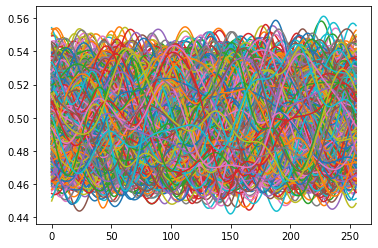

In [66]:
A = raw_data_generator(1000, 0.1, 256,256, 1.0, 0.1)

In [67]:
A['train_X'][0][0].shape

(256, 257)

In [68]:

createFolder('./data')
with open("./data/TRAIN_SHALLOW_1000_0.1_256.pickle","wb") as fw:
    pickle.dump(A, fw)


SHALLOW_WATER_1D:
  Python version: 3.9.6


C:\Users\me\AppData\Local\Programs\Python\Python39\lib\site-packages\numpy\lib\index_tricks.py:909: ComplexWarning: Casting complex values to real discards the imaginary part
  a.flat[:end:step] = val



  X  values saved in file "sw1d_x.txt"
  T  values saved in file "sw1d_t.txt"
  H  values saved in file "sw1d_h.txt"
  UH values saved in file "sw1d_uh.txt"
SHALLOW_WATER_1D:
  Normal end of execution.
0
done


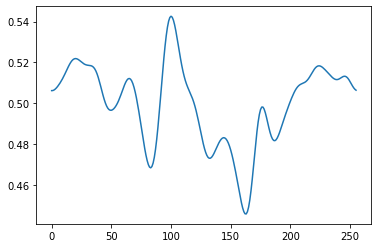

In [8]:
B = raw_data_generator(1, 0.05, 256,2560, 1.0, 1.00)

In [9]:

createFolder('./data')
with open("./data/TEST_SHALLOW_1_0.05_256.pickle","wb") as fw:
    pickle.dump(B, fw)

c:\users\me\appdata\local\programs\python\python39\lib\site-packages\numpy\lib\index_tricks.py:909: ComplexWarning: Casting complex values to real discards the imaginary part
  a.flat[:end:step] = val


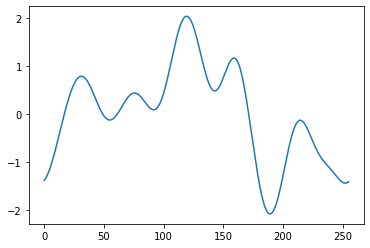

In [63]:
plt.plot(np.roll(generator_1D(covariance_2, 0.03, 256),128))